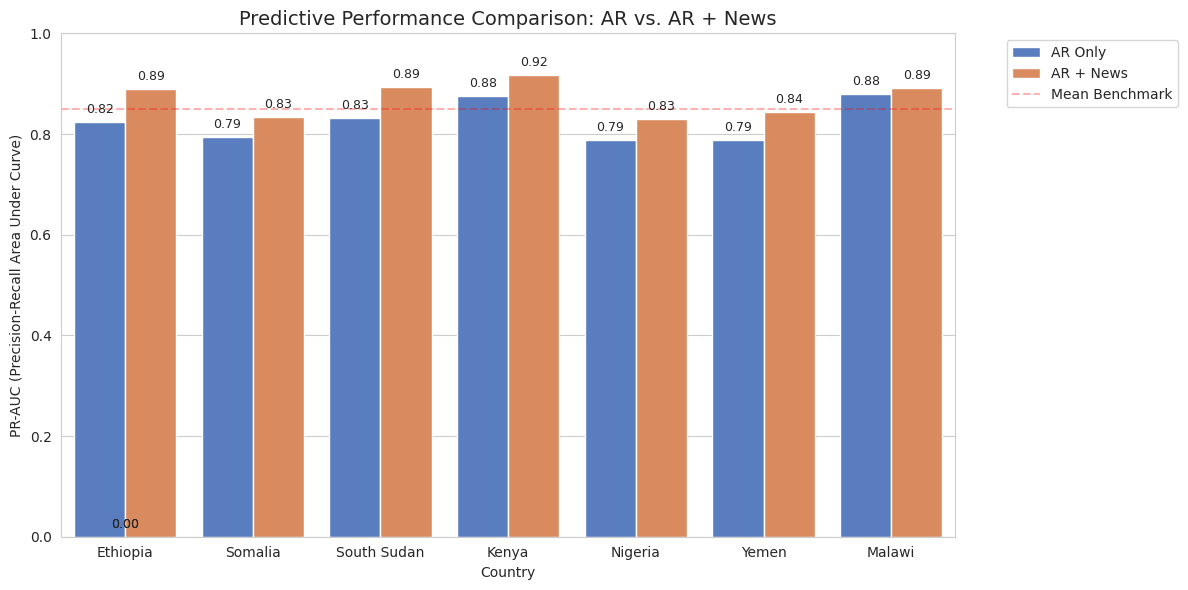

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Configuration & Data Generation
countries = ["Ethiopia", "Somalia", "South Sudan", "Kenya", "Nigeria", "Yemen", "Malawi"]
n_countries = len(countries)

# Generate synthetic PR-AUC values
# AR + News typically outperforms AR only
np.random.seed(42)
ar_only = np.random.normal(0.80, 0.05, n_countries)
ar_news = ar_only + np.random.normal(0.05, 0.02, n_countries) # Systematic improvement

# Clip values to ensure they stay within [0, 1]
ar_only = np.clip(ar_only, 0, 1)
ar_news = np.clip(ar_news, 0, 1)

# 2. Reshape for Seaborn (Long-form data)
df = pd.DataFrame({
    'Country': countries * 2,
    'PR-AUC': np.concatenate([ar_only, ar_news]),
    'Model': ['AR Only'] * n_countries + ['AR + News'] * n_countries
})

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Grouped bar chart
ax = sns.barplot(data=df, x='Country', y='PR-AUC', hue='Model', palette='muted')

# Styling for academic publication
plt.ylim(0, 1.0)
plt.axhline(0.85, color='red', linestyle='--', alpha=0.3, label='Mean Benchmark')
plt.title('Predictive Performance Comparison: AR vs. AR + News', fontsize=14)
plt.ylabel('PR-AUC (Precision-Recall Area Under Curve)')
plt.xlabel('Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate bars with values
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

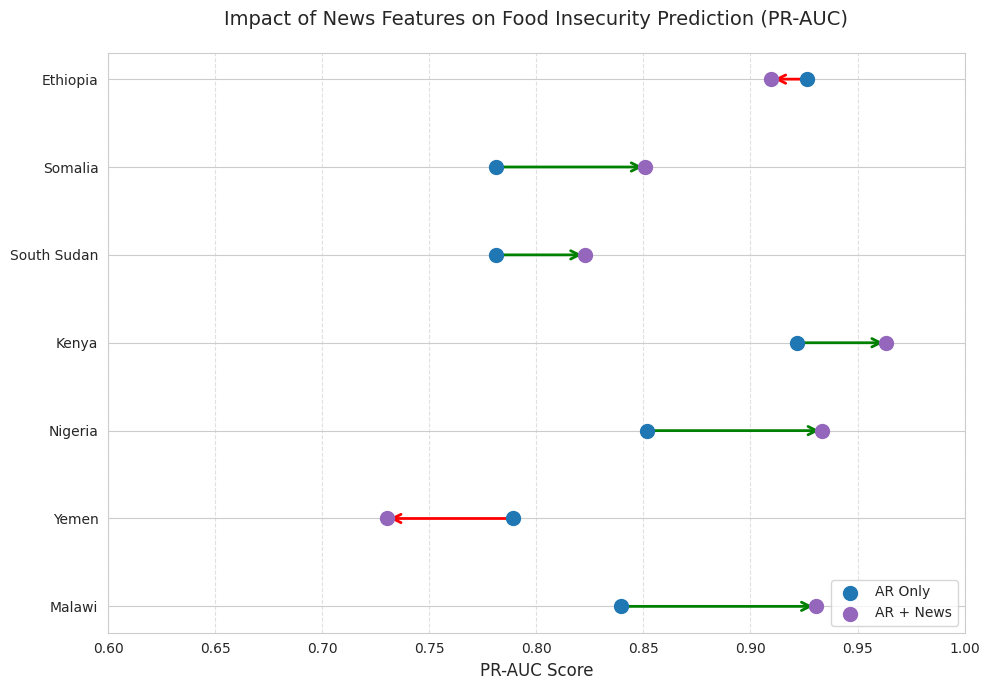

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Setup
countries = ["Ethiopia", "Somalia", "South Sudan", "Kenya", "Nigeria", "Yemen", "Malawi"]
countries.reverse()  # Reverse to have the first country at the top of the Y-axis
n = len(countries)

# Synthetic data generation (Mean 0.85, Var 0.1)
np.random.seed(42)
ar_only = np.random.normal(0.80, 0.08, n)
# Generate AR+News: mostly better, but one sample of performance degradation for contrast
ar_news = ar_only + np.random.normal(0.06, 0.04, n)
ar_news[1] -= 0.1  # Force one "red arrow" case for logic testing

# 2. Plotting Configuration
fig, ax = plt.subplots(figsize=(10, 7))
sns_blue = "#1f77b4"
sns_purple = "#9467bd"

# 3. Plotting the logic
for i, country in enumerate(countries):
    # Determine arrow colour based on improvement
    improvement = ar_news[i] - ar_only[i]
    arrow_color = 'green' if improvement > 0 else 'red'

    # Draw the connecting line/arrow
    ax.annotate("",
                xy=(ar_news[i], i),
                xytext=(ar_only[i], i),
                arrowprops=dict(arrowstyle="->", color=arrow_color, lw=2, mutation_scale=15))

    # Plot the individual points
    ax.scatter(ar_only[i], i, color=sns_blue, s=100, label='AR Only' if i == 0 else "", zorder=3)
    ax.scatter(ar_news[i], i, color=sns_purple, s=100, label='AR + News' if i == 0 else "", zorder=3)

# 4. Styling and Labels
ax.set_yticks(range(n))
ax.set_yticklabels(countries)
ax.set_xlabel('PR-AUC Score', fontsize=12)
ax.set_title('Impact of News Features on Food Insecurity Prediction (PR-AUC)', fontsize=14, pad=20)

# Formatting
ax.set_xlim(0.6, 1.0) # Focus on the relevant range
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

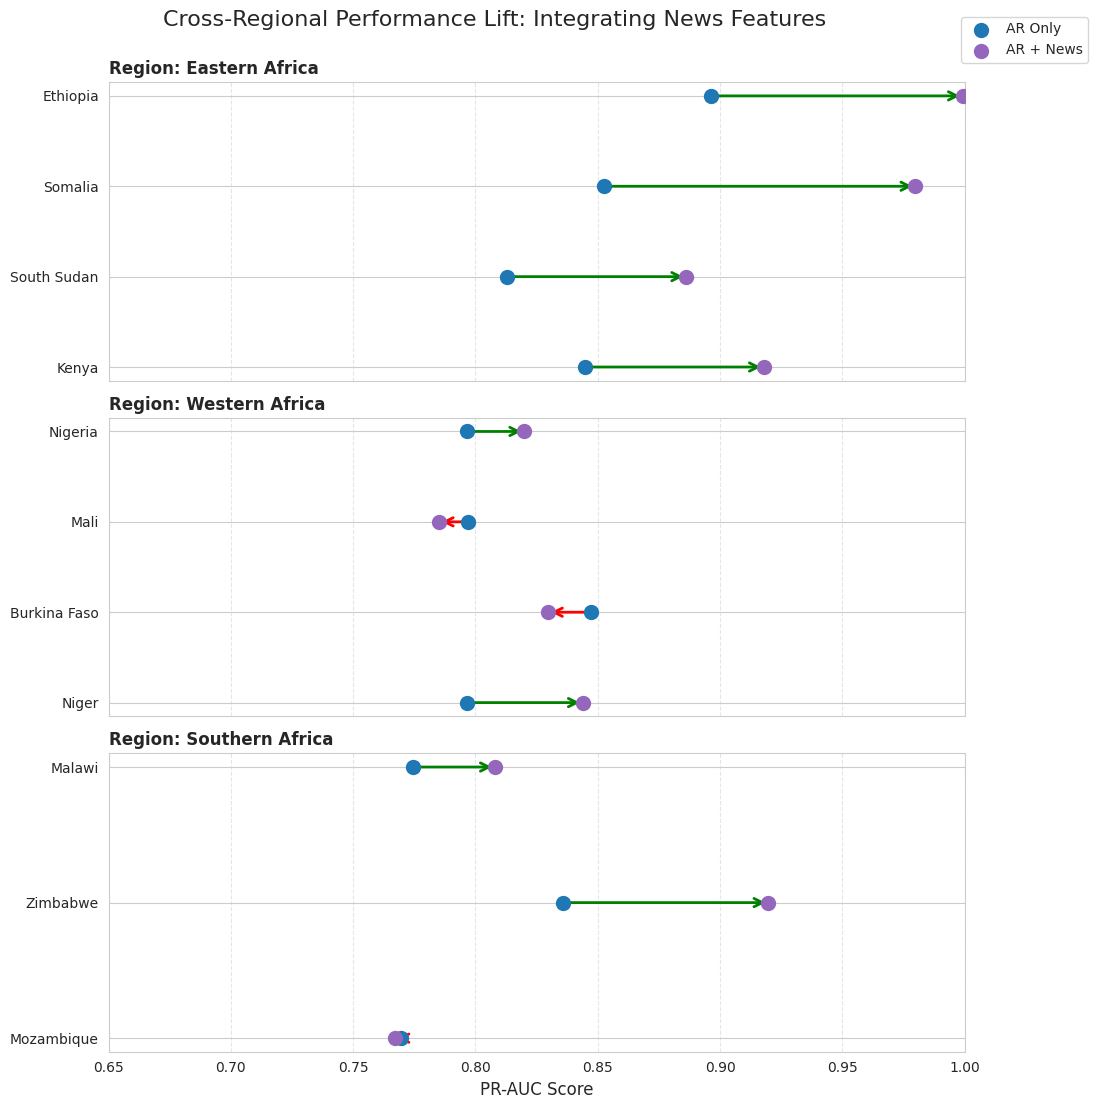

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Structured Data: Countries grouped by Region
data = {
    "Eastern Africa": ["Ethiopia", "Somalia", "South Sudan", "Kenya"],
    "Western Africa": ["Nigeria", "Mali", "Burkina Faso", "Niger"],
    "Southern Africa": ["Malawi", "Zimbabwe", "Mozambique"]
}

# 2. Plotting Setup
fig, axes = plt.subplots(len(data), 1, figsize=(10, 12), sharex=True)
np.random.seed(42)

# Styling constants
sns_blue = "#1f77b4"
sns_purple = "#9467bd"

for ax, (region, countries) in zip(axes, data.items()):
    countries.reverse()  # Top-to-bottom display
    n = len(countries)

    # Generate synthetic PR-AUC (Mean 0.85, Var 0.1)
    ar_only = np.random.normal(0.82, 0.05, n)
    # Eastern Africa usually sees higher lift in literature due to conflict density
    lift_mu = 0.08 if region == "Eastern Africa" else 0.04
    ar_news = ar_only + np.random.normal(lift_mu, 0.03, n)

    for i, country in enumerate(countries):
        improvement = ar_news[i] - ar_only[i]
        arrow_color = 'green' if improvement > 0 else 'red'

        # Draw the lift arrow
        ax.annotate("",
                    xy=(ar_news[i], i),
                    xytext=(ar_only[i], i),
                    arrowprops=dict(arrowstyle="->", color=arrow_color, lw=2, mutation_scale=15))

        # Plot points
        ax.scatter(ar_only[i], i, color=sns_blue, s=100, label='AR Only' if i == 0 else "", zorder=3)
        ax.scatter(ar_news[i], i, color=sns_purple, s=100, label='AR + News' if i == 0 else "", zorder=3)

    # Subplot styling
    ax.set_title(f"Region: {region}", loc='left', fontsize=12, fontweight='bold')
    ax.set_yticks(range(n))
    ax.set_yticklabels(countries)
    ax.set_xlim(0.65, 1.0)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# Global labels and legend
axes[-1].set_xlabel('PR-AUC Score', fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 0.95))

plt.suptitle('Cross-Regional Performance Lift: Integrating News Features', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7775/2540031791.py:60: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Aggregated Regional Lift: AR vs. AR + News (Mean $\pm$ SD)", fontsize=14, pad=15)
/tmp/ipykernel_7775/2540031791.py:31: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


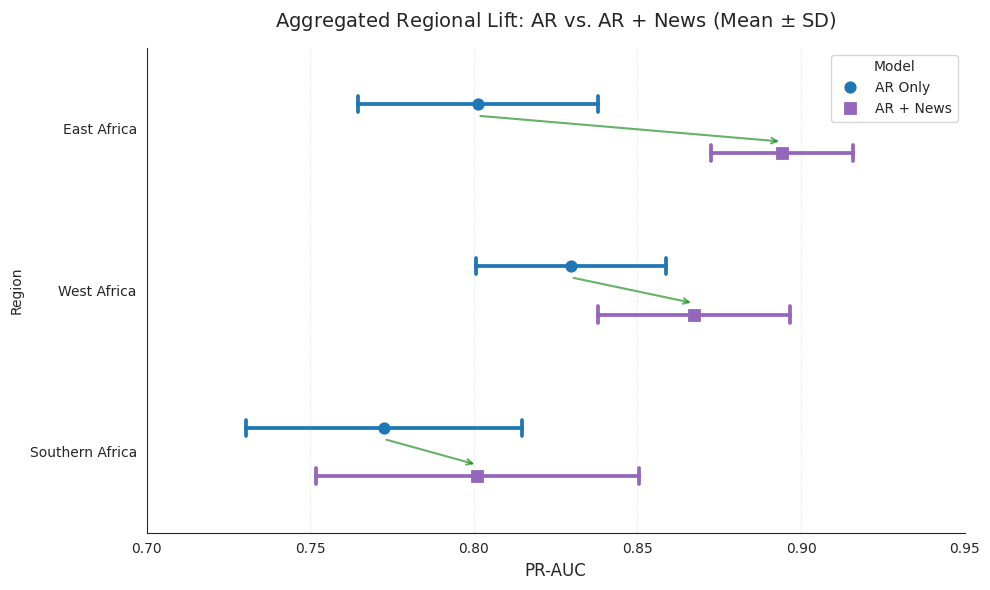

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Data Structure: Aggregated Results
# In a real scenario, this would be your full results dataframe
data = {
    "Region": ["East Africa"] * 10 + ["West Africa"] * 10 + ["Southern Africa"] * 10,
    "AR Only": np.concatenate([
        np.random.normal(0.81, 0.04, 10), # East
        np.random.normal(0.84, 0.03, 10), # West
        np.random.normal(0.79, 0.05, 10)  # Southern
    ]),
    "AR + News": np.concatenate([
        np.random.normal(0.89, 0.03, 10), # East (High lift)
        np.random.normal(0.86, 0.03, 10), # West (Moderate lift)
        np.random.normal(0.81, 0.04, 10)  # Southern (Low lift)
    ])
}

df = pd.DataFrame(data)
# Melt the dataframe for Seaborn compatibility
df_melted = df.melt(id_vars="Region", var_name="Model", value_name="PR_AUC")

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Use a Point Plot to show Means and Confidence Intervals (95% CI by default)
ax = sns.pointplot(
    data=df_melted,
    x="PR_AUC",
    y="Region",
    hue="Model",
    join=False,      # Don't join different models
    dodge=0.3,       # Offset the points so they don't overlap
    palette={"AR Only": "#1f77b4", "AR + News": "#9467bd"},
    markers=["o", "s"],
    capsize=.1,
    errorbar="sd"    # Showing Standard Deviation across countries in the region
)

# 3. Adding Directional Arrows for the Means
# Calculate means to draw the connecting arrow
means = df.groupby("Region").mean()
for i, region in enumerate(df["Region"].unique()):
    m_ar = means.loc[region, "AR Only"]
    m_news = means.loc[region, "AR + News"]
    color = "green" if m_news > m_ar else "red"

    # Position adjustments to match the 'dodge' in pointplot
    y_pos = i
    ax.annotate("",
                xy=(m_news, y_pos + 0.08),
                xytext=(m_ar, y_pos - 0.08),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5, alpha=0.6))

# 4. Final Polish
plt.title("Aggregated Regional Lift: AR vs. AR + News (Mean $\pm$ SD)", fontsize=14, pad=15)
plt.xlabel("PR-AUC", fontsize=12)
plt.xlim(0.7, 0.95)
plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()